In [6]:
import torchvision
import torch
import numpy as np
import os
import PIL.Image
import time
import copy
import seaborn as sn
import pandas as pd
import sklearn.metrics
from matplotlib import pyplot as plt
from math import ceil

In [7]:
class OstVisDataset(torch.utils.data.Dataset):
    def __init__(self, roots, transforms, subset, label_map, exclude_subfolders = None, split = (.6,.2,.2)):
        # list of root folders
        self.roots = roots

        # list of subfolders to exclude from sampling (e.g. if you only want control_well 1 and adipogenic differentiation)
        self.exclude_subfolders = exclude_subfolders

        # torchvision composed transforms
        self.transforms = transforms

        # dict mapping subfolder names to labels
        self.label_map = label_map

        # getting files
        self.enumerated_files = self.depthwise_enumerate(subset,split)

    def depthwise_enumerate(self, subset, split): 
        all_files = []
        # for each root folder
        for i in self.roots:
            # get subfolders
            folders = [f for f in os.listdir(i) if '.' not in f]
            
            if self.exclude_subfolders:
                folders = [f for f in folders if f.lower() not in self.exclude_subfolders]

            for j in folders:
                # get files from folders
                files = [i + j + '/' + f for f in os.listdir(i + j) if '.tif' in f]

                # copy files list
                files_copy = files.copy()

                # calculate sample size then select the proper subset
                train_size = ceil(len(files) * split[0])
                
                if subset == 'train':
                    upper_bound = train_size
                    files = files_copy[:upper_bound]
                elif subset == 'valid': 
                    lower_bound = train_size
                    upper_bound = train_size + ceil(len(files) * split[1])
                    files = files_copy[lower_bound:upper_bound]
                else:
                    lower_bound = train_size + ceil(len(files) * split[1])
                    files = files_copy[lower_bound:]
                
                # extend all files list by the file list for subfolder j
                all_files.extend(files)
        
        # return flat list of files
        return all_files
    
    def __len__(self):
        return len(self.enumerated_files)
    
    def __getitem__(self, idx):
        # check type
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # get image at position idx in enumerated list
        image_path = self.enumerated_files[idx]
        image = PIL.Image.open(image_path).convert('RGB')
        
        # apply tranforms
        image = self.transforms(image)
        
        # separate subfolder name from path
        image_path_parts = image_path.split('/')

        # determine label
        label = self.label_map[image_path_parts[1].lower()]
        
        # return ((path, image), output) pair We will use path to track accuracy for each class: 7 day, 10 day, etc
        return ((image_path_parts[0], image), label)

In [8]:
def load_model(device):
    model_ft = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
    num_ftrs = model_ft.fc.in_features
    # Here the size of each output sample is set to 2.
    # Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
    model_ft.fc = torch.nn.Linear(num_ftrs, 3)

    model_ft = model_ft.to(device)

    criterion = torch.nn.CrossEntropyLoss()

    # Observe that all parameters are being optimized
    optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

    # Decay LR by a factor of 0.1 every 7 epochs
    exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    return model_ft, criterion, exp_lr_scheduler, optimizer_ft

def train_model(model, criterion, optimizer, scheduler, device, dataloaders, dataset_sizes, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_epoch_accuracies = []
    val_epoch_accuracies = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)


        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0


            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs[1].to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    #print("outputs", outputs)
                    _, preds = torch.max(outputs, 1)
                    #print("preds", preds)
                    loss = criterion(outputs, labels)
                    #print(preds)
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_epoch_accuracies.append(float(epoch_acc))
            if phase == 'valid':
                val_epoch_accuracies.append(float(epoch_acc))
                
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best valid acc: {best_acc:4f}')
    plt.plot([i + 1 for i in range(num_epochs)], train_epoch_accuracies, label='Train')
    plt.plot([i + 1 for i in range(num_epochs)], val_epoch_accuracies, label = 'Validation')
    plt.legend()
    plt.xlabel('Epoch', fontname='Arial', fontsize = 12)
    plt.ylabel('Accuracy', fontname='Arial', fontsize = 12)
    plt.show()

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [9]:
# initial construction of torch Dataset object
split_names = ['train', 'valid', 'test']
roots = ['2.28/', '1day.4.13/', '3.3/', '2day.4.14/', '3day.4.15/', '3.6/', '5day.4.17/','ZOE_ALL/']
label_map = {
    'control_well 1': 0,
    'adipogenic differentiation' : 1,
    'osteogenic differentiation' : 2,
    'control' : 0,
    'adi-well-1' : 1,
    'adi-well-2' : 1,
    'ctrl-well-1' : 0,
    'ctrl-well-2' : 0,
    'ost-well-1' : 2,
    'ost-well-2' : 2,
    'osteogenic' : 2,
    'adi' : 1,
    'crl' : 0,
    'ost' : 2
}

data_transforms = {
    'train': torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.RandomResizedCrop(224),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}


datasets = {split: OstVisDataset(roots= roots,
                      transforms= data_transforms[split],
                      subset= split,
                      label_map = label_map,
                      exclude_subfolders=['split', 'ost+adi-well-1', 'ost+adi-well-2', 'adipogenic + osteogenic', 'osteogenic + adipogenic'],
                      split=(.6,.2,.2)) 
                      for split in split_names
            }

for i in datasets['train'].enumerated_files:
    if i in datasets['valid'].enumerated_files or i in datasets['test'].enumerated_files:
        print('Duplicate Found: ', i)

for i in datasets['valid'].enumerated_files:
    if i in datasets['train'].enumerated_files or i in datasets['test'].enumerated_files:
        print('Duplicate Found: ', i)

# constructing dataloaders
dataloaders = {split : torch.utils.data.DataLoader(datasets[split], shuffle=True, batch_size=128, num_workers=0) for split in split_names}

# getting lens
dataset_sizes = {split : len(datasets[split]) for split in split_names}
print(dataset_sizes)

# constructing device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load model
model_ft, criterion, exp_lr_scheduler, optimizer_ft = load_model(device)

print('Train files:', datasets['train'].enumerated_files)
print('Validation files:', datasets['valid'].enumerated_files)
print('Testing files:', datasets['test'].enumerated_files)

{'train': 1407, 'valid': 473, 'test': 456}
Train files: ['2.28/adipogenic differentiation/0228-pl2-adi-w1-df-1.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-10.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-11.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-12.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-13.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-14.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-15.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-16.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-17.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-18.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-19.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-2.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-20.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-21.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-22.tif', '2.28/adipogenic differentiati

Epoch 0/29
----------
train Loss: 1.0621 Acc: 0.4385
valid Loss: 1.0651 Acc: 0.4207

Epoch 1/29
----------
train Loss: 0.8323 Acc: 0.7591
valid Loss: 0.8935 Acc: 0.6216

Epoch 2/29
----------
train Loss: 0.6104 Acc: 0.8472
valid Loss: 0.6848 Acc: 0.7188

Epoch 3/29
----------
train Loss: 0.4592 Acc: 0.8593
valid Loss: 0.5047 Acc: 0.8457

Epoch 4/29
----------
train Loss: 0.3364 Acc: 0.9055
valid Loss: 0.4166 Acc: 0.8266

Epoch 5/29
----------
train Loss: 0.2846 Acc: 0.9083
valid Loss: 0.5262 Acc: 0.7970

Epoch 6/29
----------
train Loss: 0.2425 Acc: 0.9147
valid Loss: 0.6859 Acc: 0.7484

Epoch 7/29
----------
train Loss: 0.2162 Acc: 0.9289
valid Loss: 0.2509 Acc: 0.9154

Epoch 8/29
----------
train Loss: 0.2096 Acc: 0.9311
valid Loss: 0.2336 Acc: 0.9112

Epoch 9/29
----------
train Loss: 0.2009 Acc: 0.9303
valid Loss: 0.2342 Acc: 0.9049

Epoch 10/29
----------
train Loss: 0.2077 Acc: 0.9325
valid Loss: 0.2209 Acc: 0.9112

Epoch 11/29
----------
train Loss: 0.1943 Acc: 0.9375
valid Loss

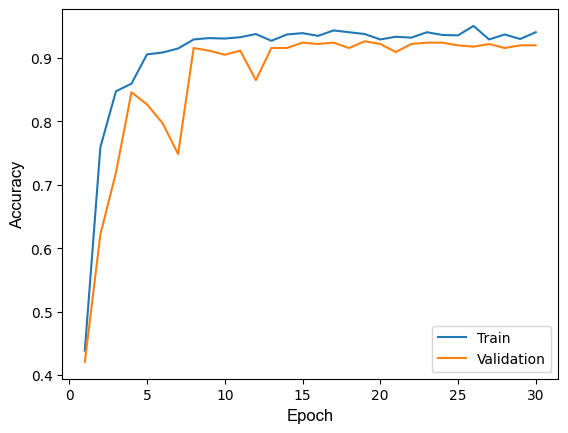

In [10]:
# train model
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,device, dataloaders, dataset_sizes,
                       num_epochs=30)

In [11]:
# only run this after training
torch.save(model_ft.state_dict(), 'OCNN_Multiclass_all_days_State_Dict_RESNET50')

In [12]:
# load model from dict
model_ft.load_state_dict(torch.load('OCNN_Multiclass_all_days_State_Dict_RESNET50'))

model_ft.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
true = []
pred = []
pred_probs = []

# making predictions
for i in dataloaders['test']:
    true.extend(list(zip([j for j in i[0][0]], [int(j) for j in i[1]])))
    evals = model_ft(i[0][1])
    pred.extend([int(torch.argmax(j)) for j in evals])
    pred_probs.extend([torch.softmax(j, 0).detach().numpy() for j in evals])

# separating class label from filename 
true_numeric = [i[1] for i in true]

# overall metrics
print('Overall Accuracy: ', sklearn.metrics.accuracy_score(true_numeric, pred))
print('Overall One vs Rest AUC: ', sklearn.metrics.roc_auc_score(true_numeric, pred_probs, multi_class='ovr', average='weighted'))

Overall Accuracy:  0.9473684210526315
Overall One vs Rest AUC:  0.9936327154635505


<Axes: >

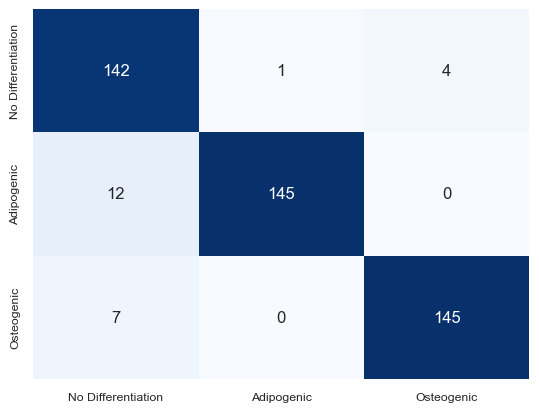

In [15]:
# labels for visual
class_names = ['No Differentiation', 'Adipogenic', 'Osteogenic']

# numeric confusion matrix
confusion_matrix = sklearn.metrics.confusion_matrix(true_numeric, pred)

# convert to df and make fancy confusion matrix
confusion_matrix_df = pd.DataFrame(confusion_matrix, index = class_names, columns = class_names)

sn.set(font_scale = .8)
sn.heatmap(confusion_matrix_df, annot=True, fmt='g', cbar=False, cmap='Blues', annot_kws={'fontsize' : 12})

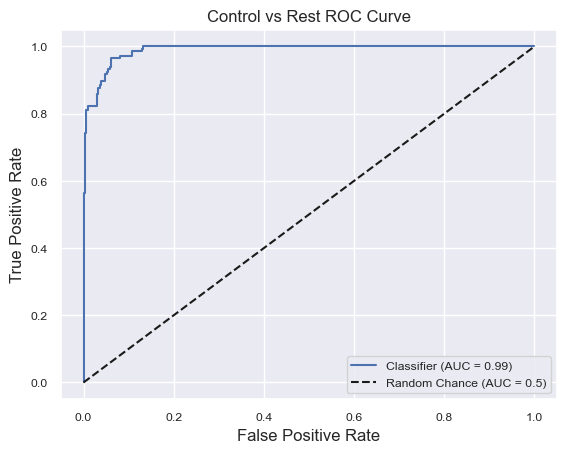

In [17]:
# Control vs Rest roc curve
control_vs_rest_true = [1 if i == 0 else 0 for i in true_numeric]
sklearn.metrics.RocCurveDisplay.from_predictions(control_vs_rest_true, np.array(pred_probs)[:,0])
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
plt.title('Control vs Rest ROC Curve', fontname='Arial', fontsize = 12)
plt.xlabel('False Positive Rate', fontname='Arial', fontsize = 12)
plt.ylabel('True Positive Rate', fontname='Arial', fontsize = 12)
plt.legend()

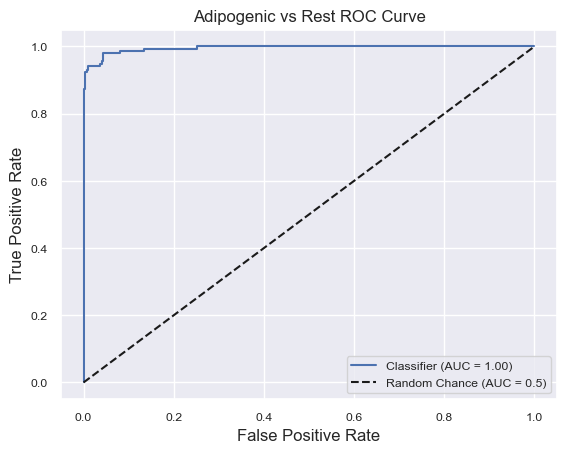

In [18]:
# Control vs Rest roc curve
adi_vs_rest_true = [1 if i == 1 else 0 for i in true_numeric]
sklearn.metrics.RocCurveDisplay.from_predictions(adi_vs_rest_true, np.array(pred_probs)[:,1])
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
plt.title('Adipogenic vs Rest ROC Curve', fontname='Arial', fontsize = 12)
plt.xlabel('False Positive Rate', fontname='Arial', fontsize = 12)
plt.ylabel('True Positive Rate', fontname='Arial', fontsize = 12)
plt.legend()

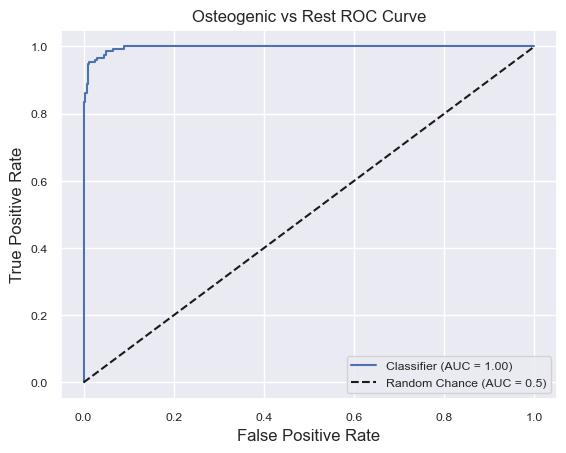

In [19]:
# Ost vs Rest roc curve
osteo_vs_rest_true = [1 if i == 2 else 0 for i in true_numeric]
sklearn.metrics.RocCurveDisplay.from_predictions(osteo_vs_rest_true, np.array(pred_probs)[:,2])
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
plt.title('Osteogenic vs Rest ROC Curve', fontname='Arial', fontsize = 12)
plt.xlabel('False Positive Rate', fontname='Arial', fontsize = 12)
plt.ylabel('True Positive Rate', fontname='Arial', fontsize = 12)
plt.legend()

In [22]:
# computing metrics by class

all = []

for i in zip(true, pred, pred_probs):
    # basically flattening the true and pred class. i[0][0] is filename, i[0][1] is true class, i[1] is prediction
    all.append((i[0][0], i[0][1], i[1], i[2]))

# convert to dataframe for easy slicing
all_preds_and_labels = pd.DataFrame(all, columns=['File Group', 'True Class', 'Prediction', 'Predicted Probs'])
metrics_dict = dict()

#print(all_preds_and_labels)

# compute metrics for each filename
for i in set(all_preds_and_labels['File Group']):
    slice = all_preds_and_labels[all_preds_and_labels['File Group'] == i]
    metrics_dict['{} Accuracy'.format(i)] = sklearn.metrics.accuracy_score(np.array(slice['True Class']), np.array(slice['Prediction']))
    metrics_dict['{} Overall One vs Rest AUC'.format(i)] = sklearn.metrics.roc_auc_score(slice['True Class'], [j for j in slice['Predicted Probs']], multi_class='ovr', labels=[0, 1, 2])

for i in metrics_dict.items():
    print(i)

('5day.4.17 Accuracy', 0.9166666666666666)
('5day.4.17 Overall One vs Rest AUC', 0.9866666666666667)
('3.3 Accuracy', 1.0)
('3.3 Overall One vs Rest AUC', 1.0)
('2day.4.14 Accuracy', 0.9661016949152542)
('2day.4.14 Overall One vs Rest AUC', 0.9986954565901934)
('2.28 Accuracy', 0.9473684210526315)
('2.28 Overall One vs Rest AUC', 1.0)
('ZOE_ALL Accuracy', 0.9661016949152542)
('ZOE_ALL Overall One vs Rest AUC', 0.9892825011246064)
('1day.4.13 Accuracy', 0.9473684210526315)
('1day.4.13 Overall One vs Rest AUC', 0.9990766389658358)
('3day.4.15 Accuracy', 0.864406779661017)
('3day.4.15 Overall One vs Rest AUC', 0.9832546108861898)
('3.6 Accuracy', 0.9821428571428571)
('3.6 Overall One vs Rest AUC', 0.9990230764224574)


In [ ]:
true_train = []

for i in dataloaders['train']:
    true_train.extend(list(zip([j for j in i[0][0]], [int(j) for j in i[1]], [j for j in range(len(i[1]))])))
print(true_train)
all_train_labels = pd.DataFrame(true_train, columns=['File Group', 'True Class', 'ID'])

[('ZOE_ALL', 0, 0), ('5day.4.17', 2, 1), ('2.28', 2, 2), ('ZOE_ALL', 3, 3), ('2.28', 0, 4), ('3day.4.15', 1, 5), ('3.3', 3, 6), ('ZOE_ALL', 0, 7), ('3.3', 3, 8), ('2.28', 3, 9), ('3day.4.15', 2, 10), ('3.6', 3, 11), ('ZOE_ALL', 1, 12), ('2.28', 3, 13), ('3day.4.15', 0, 14), ('3.3', 0, 15), ('ZOE_ALL', 1, 16), ('5day.4.17', 2, 17), ('3.6', 0, 18), ('ZOE_ALL', 3, 19), ('2.28', 1, 20), ('5day.4.17', 0, 21), ('2.28', 1, 22), ('3.6', 2, 23), ('3.6', 0, 24), ('ZOE_ALL', 0, 25), ('1day.4.13', 0, 26), ('2.28', 1, 27), ('3.3', 2, 28), ('3.6', 3, 29), ('2day.4.14', 0, 30), ('2day.4.14', 2, 31), ('2.28', 2, 32), ('2day.4.14', 0, 33), ('3.6', 2, 34), ('ZOE_ALL', 1, 35), ('ZOE_ALL', 2, 36), ('3.3', 1, 37), ('1day.4.13', 0, 38), ('2.28', 2, 39), ('1day.4.13', 1, 40), ('ZOE_ALL', 1, 41), ('3day.4.15', 1, 42), ('3.6', 0, 43), ('3.3', 2, 44), ('ZOE_ALL', 2, 45), ('5day.4.17', 2, 46), ('ZOE_ALL', 1, 47), ('1day.4.13', 2, 48), ('3.6', 2, 49), ('2day.4.14', 1, 50), ('2day.4.14', 1, 51), ('2day.4.14', 2, 5

In [ ]:
test_label_counts = all_preds_and_labels.groupby(['True Class', 'File Group']).count()
print(test_label_counts)

                       Prediction  Predicted Probs
True Class File Group                             
0          1day.4.13           19               19
           2.28                20               20
           2day.4.14           19               19
           3.3                 10               10
           3.6                 19               19
           3day.4.15           20               20
           5day.4.17           20               20
           ZOE_ALL             20               20
1          1day.4.13           19               19
           2.28                18               18
           2day.4.14           20               20
           3.3                 20               20
           3.6                 20               20
           3day.4.15           20               20
           5day.4.17           20               20
           ZOE_ALL             20               20
2          1day.4.13           19               19
           2.28                

In [ ]:
train_label_counts = all_train_labels.groupby(['True Class', 'File Group']).count()
print(train_label_counts)

                       ID
True Class File Group    
0          1day.4.13   62
           2.28        60
           2day.4.14   62
           3.3         30
           3.6         60
           3day.4.15   60
           5day.4.17   60
           ZOE_ALL     60
1          1day.4.13   62
           2.28        59
           2day.4.14   60
           3.3         60
           3.6         60
           3day.4.15   60
           5day.4.17   60
           ZOE_ALL     60
2          1day.4.13   61
           2.28        59
           2day.4.14   60
           3.3         59
           3.6         53
           3day.4.15   59
           5day.4.17   60
           ZOE_ALL     61
3          2.28        60
           3.3         60
           3.6         60
           ZOE_ALL     63
